<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/MOVIE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import ast
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# LOAD THE DATASETS

In [ ]:
movies = pd.read_csv('tmdb_5000_movies.csv')
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


# LOAD THE DATASET

In [ ]:
credits = pd.read_csv("tmdb_5000_credits.csv")
credits.head()

/tmp/ipykernel_2361/2775106915.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,26

,movie_id,title,cast,crew,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# MERGE THE DATASET

In [ ]:
movies = movies.merge(credits,on='title')
display(movies.head())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# KEEP IMPORTANT COLUMNS

In [ ]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
display(movies.head())

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
print(movies.shape)

(1492, 7)


# CHECK FOR MISSING VALUES

In [ ]:
movies.isnull().sum()

,0
movie_id,0
title,0
overview,0
genres,0
keywords,0
cast,0
crew,3


# DROP MISSING VALUES

In [ ]:
movies.dropna(inplace=True)
movies.isnull().sum()

,0
movie_id,0
title,0
overview,0
genres,0
keywords,0
cast,0
crew,0


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1489 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  1489 non-null   object
 1   title     1489 non-null   object
 2   overview  1489 non-null   object
 3   genres    1489 non-null   object
 4   keywords  1489 non-null   object
 5   cast      1489 non-null   object
 6   crew      1489 non-null   object
dtypes: object(7)
memory usage: 93.1+ KB


In [ ]:
movies.describe()

,movie_id,title,overview,genres,keywords,cast,crew
count,1489,1489,1489,1489,1489,1489,1489
unique,1487,1487,1489,619,1456,1487,1487
top,72710,The Host,The Dynamic Duo faces four super-villains who ...,"[{""id"": 35, ""name"": ""Comedy""}]",[],"[{""cast_id"": 52, ""character"": ""Melanie Stryder...","[{""credit_id"": ""52fe487bc3a368484e0fa919"", ""de..."
freq,2,2,1,71,29,2,2


# DATA PREPROCESSING

The columns genres, keywords, cast, crew are stored as JSON-like strings.

Convert them to lists.

# CONVERT OBJECT

In [ ]:
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

# APPLY

In [ ]:
def convert(obj):
    # Check if the object is already a list to prevent re-processing
    if isinstance(obj, list):
        return obj
    L = []
    try:
        parsed_data = ast.literal_eval(obj)
        for i in parsed_data:
            # Ensure 'name' key exists to prevent KeyError
            if 'name' in i:
                L.append(i['name'])
    except (ValueError, SyntaxError) as e:
        # Handle cases where the string is malformed or not a valid literal
        # print(f"Warning: Could not parse string: {obj}. Error: {e}") # Optional: for debugging
        return [] # Return an empty list for malformed entries
    return L

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert)
movies['crew'] = movies['crew'].apply(convert)

# FIRST 5 ROWS OF THE MERGED DATAFRAME.

In [ ]:
display(movies.head())

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter..."


In [ ]:
print(movies.columns.tolist())

['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']


# MERGE MOVIE AND CREDIT ON 'TITLE'

In [ ]:
movies = movies.merge(credits, on='title')
display(movies.head())

,movie_id_x,title,overview,genres,keywords,cast_x,crew_x,movie_id_y,cast_y,crew_y,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# REMOVE UNNAMED COLUMNS FROM 'CREDIT' DATAFRAME

In [ ]:
credits = credits.loc[:, ~credits.columns.str.contains('^Unnamed')]
display(credits.head())

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
display(credits.head())

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
display(movies.head())

,movie_id_x,title,overview,genres,keywords,cast_x,crew_x,movie_id_y,cast_y,crew_y,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(movies['genres'])

,genres
0,"[Action, Adventure, Fantasy, Science Fiction]"
1,"[Adventure, Fantasy, Action]"
2,"[Action, Adventure, Crime]"
3,"[Action, Crime, Drama, Thriller]"
4,"[Action, Adventure, Science Fiction]"
...,...
1484,[Drama]
1485,"[Action, Crime, Thriller]"
1486,"[Comedy, Drama]"
1487,"[Horror, Drama, Science Fiction]"


# Step 6 — Extract Top Cast


In [ ]:
def convert_cast(obj):
    L = []
    counter = 0
    # Add a check for non-string types or already processed lists
    if not isinstance(obj, str):
        return [] # Or handle based on expected input type
    try:
        parsed_data = ast.literal_eval(obj)
        for i in parsed_data:
            if counter < 3:
                if 'name' in i:
                    L.append(i['name'])
                counter+=1
            else:
                break
    except (ValueError, SyntaxError) as e:
        # Handle cases where the string is malformed or not a valid literal
        return [] # Return an empty list for malformed entries
    return L

movies['cast_y'] = movies['cast_y'].apply(convert_cast)

# INSPECT THE FIRST 10 ENTRIES OF THE 'CAST_Y'

In [ ]:
display(movies['cast_y'].head(10))

,cast_y
0,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]"
1,"[Johnny Depp, Orlando Bloom, Keira Knightley]"
2,"[Daniel Craig, Christoph Waltz, Léa Seydoux]"
3,"[Christian Bale, Michael Caine, Gary Oldman]"
4,"[Taylor Kitsch, Lynn Collins, Samantha Morton]"
5,"[Tobey Maguire, Kirsten Dunst, James Franco]"
6,"[Zachary Levi, Mandy Moore, Donna Murphy]"
7,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff..."
8,"[Daniel Radcliffe, Rupert Grint, Emma Watson]"
9,"[Ben Affleck, Henry Cavill, Gal Gadot]"


# DISPLAY THE FIRST 5 ROWS OF THE 'MOVIES' DATAFRAME WITH THE NEW 'CAST_Y' COLUMN

In [ ]:
display(movies.head())

,movie_id_x,title,overview,genres,keywords,cast_x,crew_x,movie_id_y,cast_y,crew_y,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",19995,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",285,"[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",49026,"[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",49529,"[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# EXTRACT DIRECTORS

In [ ]:
def fetch_director(obj):
    L = []
    if not isinstance(obj, str):
        return [] # Or handle based on expected input type
    try:
        parsed_data = ast.literal_eval(obj)
        for i in parsed_data:
            if i['job'] == 'Director':
                if 'name' in i:
                    L.append(i['name'])
                break
    except (ValueError, SyntaxError) as e:
        # Handle cases where the string is malformed or not a valid literal
        return [] # Return an empty list for malformed entries
    return L

movies['crew_y'] = movies['crew_y'].apply(fetch_director)

# DISPLAY FIRST 5 ROWS OF THE MOVIE  

In [ ]:
# Flatten the list of lists in 'crew_y' and count unique directors
all_directors = [director for sublist in movies['crew_y'] for director in sublist]
unique_directors_count = len(set(all_directors))

print(f"Number of unique directors extracted: {unique_directors_count}")

Number of unique directors extracted: 663


# TOP 10 MOST FREQUENT DIRECTORS

In [ ]:
from collections import Counter

director_counts = Counter(all_directors)
top_10_directors = director_counts.most_common(10)

print("Top 10 Most Frequent Directors:")
for director, count in top_10_directors:
    print(f"- {director}: {count}")

Top 10 Most Frequent Directors:
- Steven Spielberg: 18
- Ridley Scott: 12
- Robert Zemeckis: 11
- Ron Howard: 11
- Clint Eastwood: 11
- Tim Burton: 10
- Michael Bay: 10
- Martin Scorsese: 9
- David Fincher: 9
- Tony Scott: 9


# MOVIE DF DISPLAYED WITH 'CREW_Y' UPDATED TO SHOW ONLY THE DIRECTOR'S NAME FOR EACH MOVIE.

In [ ]:
display(movies.head())

,movie_id_x,title,overview,genres,keywords,cast_x,crew_x,movie_id_y,cast_y,crew_y,...,Unnamed: 1255,Unnamed: 1256,Unnamed: 1257,Unnamed: 1258,Unnamed: 1259,Unnamed: 1260,Unnamed: 1261,Unnamed: 1262,Unnamed: 1263,Unnamed: 1264
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",19995,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",285,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",49026,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",49529,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Step 8 — Process Overview

Split overview text

In [ ]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())

# Step 9 — Create Tags Feature

Combine all features.

In [ ]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast_y'] + movies['crew_y']

# CHECK FOR NULL VALUES IN THE 'TAG' COLUMN

In [ ]:
print(movies['tags'].isnull().sum())

0


# SHOW FIRST 5 ENTRIES IN THE 'TAGS' COLUMN

In [ ]:
display(movies['tags'].head())

,tags
0,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,"[Captain, Barbossa,, long, believed, to, be, d..."
2,"[A, cryptic, message, from, Bond’s, past, send..."
3,"[Following, the, death, of, District, Attorney..."
4,"[John, Carter, is, a, war-weary,, former, mili..."


# Create new dataframe:

In [ ]:
new_df = movies[['movie_id_x','title','tags']]

# SHOW THE FIRST 5 ENTRIES OF THE NEW DATAFRAME 'new_df'

In [ ]:
display(new_df.head())

,movie_id_x,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


# Convert list to string:

In [ ]:
new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))

/tmp/ipykernel_2361/3089450492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))


# Step 10 — Text Vectorization

Use Bag of Words from Scikit-Learn.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')



#CALCULATE COSINE SIMILARITY BETWEEN MOVIES USING TF-IDF MATRIX

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# The definition of 'vectors' was previously in a later cell and is included here for correctness.
# Ensure 'cv' and 'new_df' are defined before this cell is run.
# Assuming 'cv' and 'new_df' are already defined in the kernel state from previous executions.
v = CountVectorizer(max_features=5000,stop_words='english')
vectors = v.fit_transform(new_df['tags']).toarray()

similarity = cosine_similarity(vectors)
print(f"Similarity Matrix Shape: {similarity.shape}")

Similarity Matrix Shape: (1489, 1489)


# TRANFORM TEXT

In [ ]:
vectors = cv.fit_transform(new_df['tags']).toarray()
print(f"✔ TF-IDF Matrix Shape: {vectors.shape}")
print(f"   → {vectors.shape[0]} movies  ×  {vectors.shape[1]} unique terms\n")

✔ TF-IDF Matrix Shape: (1489, 5000)
   → 1489 movies  ×  5000 unique terms



# ANALYSE THE 'NEW_DF' DATAFRAME COLUMS

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1489 entries, 0 to 1488
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   movie_id_x  1489 non-null   object
 1   title       1489 non-null   object
 2   tags        1489 non-null   object
dtypes: object(3)
memory usage: 35.0+ KB


# FINDING THE TOP 5 SIMILAR MOVIES FOR A SPECIFIC MOVIE

In [ ]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x:x[1])[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

Now, let's try to get recommendations for a movie. For example, 'Avatar'.

In [ ]:
recommend('Avatar')

Alien³
Mission to Mars
Lost in Space
Treasure Planet
Dune


# VISUALIZE MOVIE GENRES DISTRIBUTION

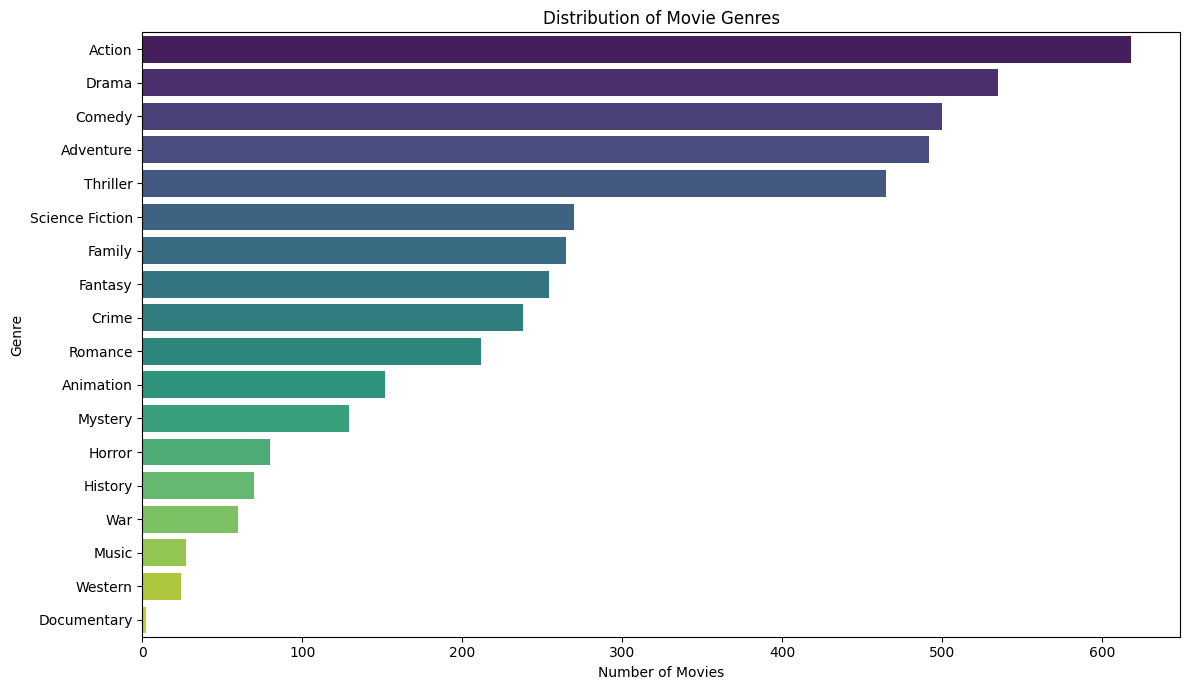

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list of lists in the 'genres' column
all_genres = [genre for sublist in movies['genres'] for genre in sublist]

# Count the occurrences of each genre
genre_counts = Counter(all_genres)

# Convert to a DataFrame for easier plotting
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Genre', data=genre_df, palette='viridis', hue='Genre', legend=False)
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# DISTRIBUTION OF MOVIE RELEASE YEARS

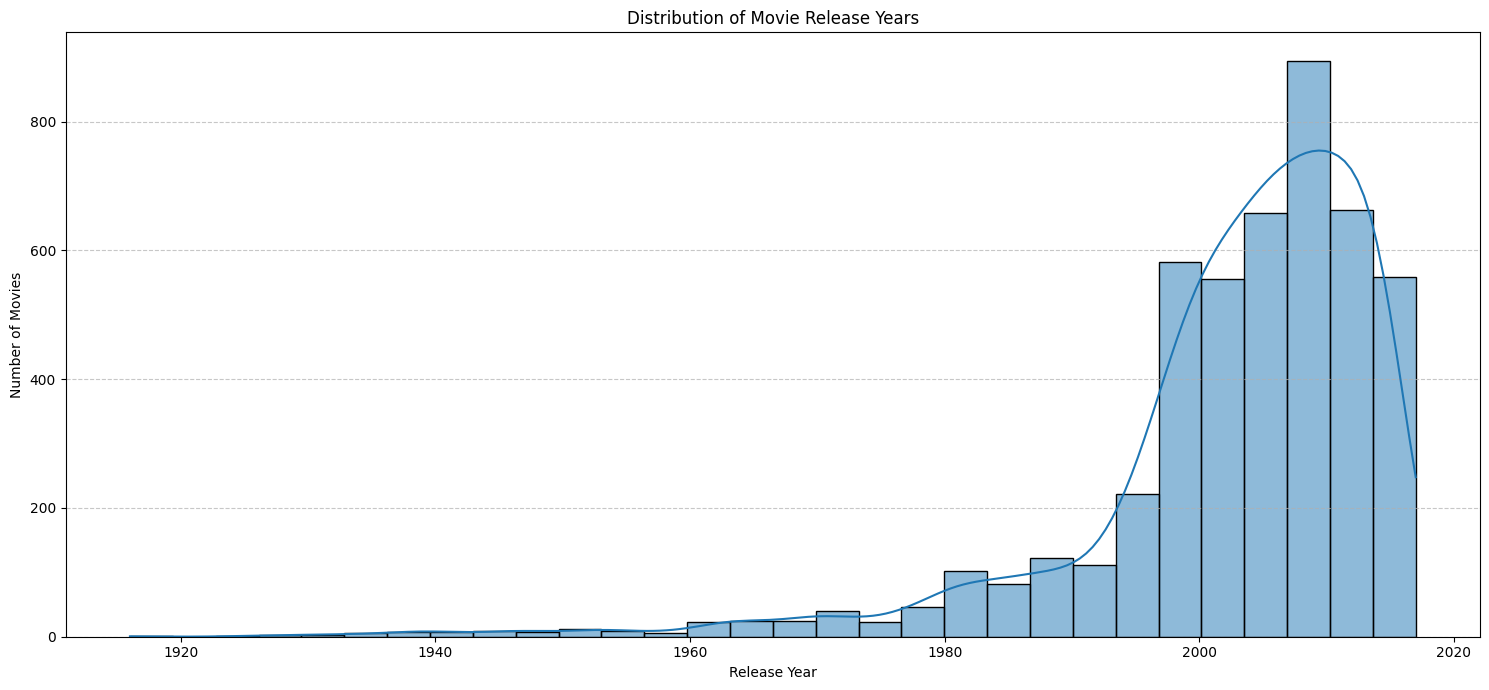

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original movies dataset to access 'release_date'
temp_movies_df = pd.read_csv('tmdb_5000_movies.csv')

# Convert 'release_date' to datetime objects and extract the year (will be float with NaNs)
temp_movies_df['release_year'] = pd.to_datetime(temp_movies_df['release_date'], errors='coerce').dt.year

# Drop rows where 'release_year' is NaN before converting to int
temp_movies_df.dropna(subset=['release_year'], inplace=True)

# Convert the year to integer type
temp_movies_df['release_year'] = temp_movies_df['release_year'].astype(int)

# Plot the distribution of release years
plt.figure(figsize=(15, 7))
sns.histplot(temp_movies_df['release_year'], bins=30, kde=True)
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# CALCULATE SIMILARITY

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vectors)

# RECOMMENDATION FUNCTION

In [ ]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

# SAVE THE MODEL

Save files for web app.

In [ ]:
import pickle

pickle.dump(new_df,open('movie_list.pkl','wb'))
pickle.dump(similarity,open('similarity.pkl','wb'))

In [ ]:
#DOWNLOAD
from google.colab import files
files.download('movie_list.pkl')
files.download('similarity.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DISCLAIMER
EVERYTHING OUTSIDE THIS CODE IS (OPTIONAL) SINCE IT IS THE PART WHERE I LOAD THE DOWNLOADED .PKL FILES BACK  

First, you need to upload the `movie_list.pkl` and `similarity.pkl` files from your local machine to your Colab runtime. You can do this by running the following cell, which will open a file selection dialog.

Once the files are uploaded, you can load them back into your Python environment using `pickle.load()`:

In [ ]:
import pickle
import pandas as pd

# Load movie_list.pkl
with open('movie_list.pkl', 'rb') as f:
    loaded_movie_list = pickle.load(f)

# Load similarity.pkl
with open('similarity.pkl', 'rb') as f:
    loaded_similarity_matrix = pickle.load(f)

print("Downloaded files loaded back into Colab variables:")
print(f"Type of loaded_movie_list: {type(loaded_movie_list)}")
display(loaded_movie_list.head())
print(f"Type of loaded_similarity_matrix: {type(loaded_similarity_matrix)}")
print(f"Shape of loaded_similarity_matrix: {loaded_similarity_matrix.shape}")

Downloaded files loaded back into Colab variables:
Type of loaded_movie_list: <class 'pandas.core.frame.DataFrame'>


,movie_id_x,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


Type of loaded_similarity_matrix: <class 'numpy.ndarray'>
Shape of loaded_similarity_matrix: (1489, 1489)


# INSTALL STREAMLIT

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.5 MB/s eta 0:00:00


#RUN STREAMLIT

In [ ]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


RUN THE REQIREMENT TXT

In [ ]:
%%writefile requirements.txt
autots
numpy
pandas
matplotlib
seaborn
scikit-learn
tensorflow
joblib
streamlit
!pip install -r requirements.txt

Writing requirements.txt


# BELOW IS THE LIST OF ALL AVAILABLE FILES IN THE /CONTENT/ DIRECTORY.

In [ ]:
!ls -l /content/

total 46820
-rw-r--r-- 1 root root   779028 Mar 23 14:31 movie_list.pkl
-rw-r--r-- 1 root root      113 Mar 23 14:31 requirements.txt
drwxr-xr-x 1 root root     4096 Mar 17 17:58 sample_data
-rw-r--r-- 1 root root 17737132 Mar 23 14:31 similarity.pkl
-rw-r--r-- 1 root root 23709406 Mar 23 14:30 tmdb_5000_credits.csv
-rw-r--r-- 1 root root  5698602 Mar 23 14:30 tmdb_5000_movies.csv
